# Symbolic network on MNIST 0 vs 1 — Milestone A

Implements the Milestone A target from `docs/research/hybrid_symbolic_networks.md`:

- `SymbolicNetwork` dataclass: **K=4 layer-1 feature trees + 1 layer-2 classifier tree**
- Network-aware GP: mutation operates on one tree slot within the network
- 2-class problem: **MNIST digit 0 vs digit 1** (binary, easiest contrast)
- **Success criterion**: TEST accuracy > 0.95

Per `tessera/experimental/symbolic_network.py`. This is Colab-runnable — installs tessera from GitHub if needed.

```
image (28x28)
  │
  ├─→ T_1(image) ─→ mean-pool ─→ f_0 ─┐
  ├─→ T_2(image) ─→ mean-pool ─→ f_1 ─┤
  ├─→ T_3(image) ─→ mean-pool ─→ f_2 ─├─→ T_clf(f_0,f_1,f_2,f_3) ─→ score ─→ sigmoid → class
  └─→ T_4(image) ─→ mean-pool ─→ f_3 ─┘
```

GP unit = the whole (4+1)-tree network. Mutation picks one slot per step.

## 1. Setup

If running locally with the repo already cloned, just skip the git clone cell.

In [1]:
# Cell 1.1 — Robust setup: clone, install, verify. Works in Colab + locally.
import os, sys, subprocess

REPO_DIR = 'tessera'

# Clone if not present (handles re-running the cell)
if not os.path.exists(REPO_DIR):
    print('Cloning tessera...')
    r = subprocess.run(['git', 'clone', '--depth', '1',
                        'https://github.com/davechendatascience/tessera.git'],
                       capture_output=True, text=True)
    if r.returncode != 0:
        print('git clone FAILED:', r.stderr); raise RuntimeError('clone failed')
else:
    # Pull latest if dir already exists (handles re-running after upstream updates)
    print(f'{REPO_DIR}/ already exists; pulling latest...')
    subprocess.run(['git', '-C', REPO_DIR, 'pull', '--ff-only'],
                   capture_output=True, text=True)

# Verify the experimental subpackage IS in the cloned tree before installing
exp_path = os.path.join(REPO_DIR, 'src', 'tessera', 'experimental')
if not os.path.exists(exp_path):
    raise RuntimeError(f'Expected {exp_path} after clone — repo structure mismatch.')
print(f'✓ {exp_path} exists with files: '
      f'{sorted(f for f in os.listdir(exp_path) if f.endswith(".py"))[:5]}...')

# Install editable. NO --quiet so failures are visible. extras include
# jax + benchmark dependencies (sklearn, matplotlib, requests, netCDF4, pyarrow).
print('\nInstalling tessera + benchmarks + jax (editable)...')
r = subprocess.run([sys.executable, '-m', 'pip', 'install', '-e',
                    f'./{REPO_DIR}[benchmarks,jax]'],
                   capture_output=True, text=True)
if r.returncode != 0:
    print('pip install warning — last lines of stderr:')
    print(r.stderr.splitlines()[-10:])
else:
    print('pip install completed.')

# ROBUST FALLBACK: also add src/ to sys.path. The editable install
# should make this unnecessary, but if it failed silently, this fallback
# makes the imports work anyway.
src_abs = os.path.abspath(os.path.join(REPO_DIR, 'src'))
if src_abs not in sys.path:
    sys.path.insert(0, src_abs)

# Verify the import that matters for this notebook
try:
    import tessera
    from tessera.experimental.symbolic_network import SymbolicNetwork
    print(f'\n✓ tessera at: {tessera.__file__}')
    print(f'✓ tessera.experimental.symbolic_network importable')
except Exception as e:
    print(f'\n✗ IMPORT STILL FAILED: {type(e).__name__}: {e}')
    print('Diagnostic info:')
    print(f'  cwd: {os.getcwd()}')
    print(f'  src_abs: {src_abs}, exists: {os.path.exists(src_abs)}')
    print(f'  sys.path[:3]: {sys.path[:3]}')
    raise


Cloning tessera...
✓ tessera/src/tessera/experimental exists with files: ['__init__.py', 'abc_scoring.py', 'adaptive_search.py', 'additive_polynomial.py', 'causal_axes.py']...

Installing tessera + benchmarks + jax (editable)...
pip install completed.

✓ tessera at: /content/tessera/src/tessera/__init__.py
✓ tessera.experimental.symbolic_network importable


In [2]:
# Cell 1.2 — Imports.
import random
import time
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml

from tessera.experimental.symbolic_network import (
    SymbolicNetwork, NetworkGPConfig, run_network_gp,
    network_accuracy, evaluate_network,
)
from tessera.expression.tree import evaluate as eval_tree

print('tessera.experimental.symbolic_network loaded')

# Check JAX device — should show GPU on Colab GPU runtime
import jax
print(f'JAX devices: {jax.devices()}')
if any('cuda' in str(d).lower() or 'gpu' in str(d).lower() for d in jax.devices()):
    print('  → GPU runtime detected; JAX batched eval will use GPU.')
else:
    print('  → CPU only. For GPU speedup, switch Colab runtime to GPU.')


tessera.experimental.symbolic_network loaded
JAX devices: [CudaDevice(id=0)]
  → GPU runtime detected; JAX batched eval will use GPU.


## 2. Load MNIST digits 0 vs 1

- Subset to digits 0 and 1 only
- Downsample 28×28 → 14×14 (2× block-mean) for GP speed
- 400 TRAIN / 200 TEST per class, stratified

In [3]:
# Cell 2 — Load + preprocess MNIST 0 vs 1.
SEED = 2026
TARGET_A, TARGET_B = 0, 1   # the two classes
N_PER_TRAIN = 400
N_PER_TEST  = 200
IMG_SIZE = 14               # downsampled from 28

def downsample_2x(img):
    """28×28 → 14×14 via 2×2 block-mean."""
    return img.reshape(14, 2, 14, 2).mean(axis=(1, 3))

print('Fetching MNIST via sklearn (cached after first call)...')
t0 = time.time()
mnist = fetch_openml('mnist_784', version=1, as_frame=False, cache=True)
print(f'  done in {time.time()-t0:.1f}s')
X = mnist.data.reshape(-1, 28, 28).astype(np.float32) / 255.0
y = mnist.target.astype(int)

rng_data = np.random.default_rng(SEED)
idx_a = rng_data.permutation(np.where(y == TARGET_A)[0])
idx_b = rng_data.permutation(np.where(y == TARGET_B)[0])

tr_a, tr_b = idx_a[:N_PER_TRAIN], idx_b[:N_PER_TRAIN]
te_a, te_b = idx_a[N_PER_TRAIN:N_PER_TRAIN+N_PER_TEST], idx_b[N_PER_TRAIN:N_PER_TRAIN+N_PER_TEST]

tr_idx = np.concatenate([tr_a, tr_b])
te_idx = np.concatenate([te_a, te_b])
rng_data.shuffle(tr_idx); rng_data.shuffle(te_idx)

imgs_train_full = X[tr_idx]
labels_train = (y[tr_idx] == TARGET_B).astype(int)  # 0 if digit=0, 1 if digit=1
imgs_test_full  = X[te_idx]
labels_test  = (y[te_idx] == TARGET_B).astype(int)

imgs_train = np.stack([downsample_2x(im) for im in imgs_train_full], axis=0)
imgs_test  = np.stack([downsample_2x(im) for im in imgs_test_full], axis=0)

print(f'TRAIN: {imgs_train.shape}, labels = {np.bincount(labels_train)}')
print(f'TEST:  {imgs_test.shape}, labels = {np.bincount(labels_test)}')

Fetching MNIST via sklearn (cached after first call)...
  done in 15.8s
TRAIN: (800, 14, 14), labels = [400 400]
TEST:  (400, 14, 14), labels = [200 200]


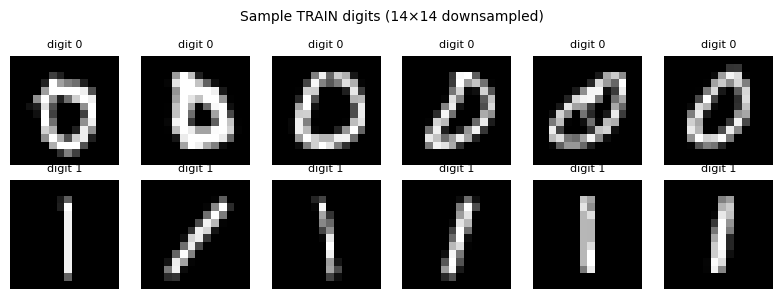

In [4]:
# Cell 2.1 — Visualize sample digits.
fig, axes = plt.subplots(2, 6, figsize=(8, 3))
for i in range(6):
    j0 = np.where(labels_train == 0)[0][i]
    j1 = np.where(labels_train == 1)[0][i]
    axes[0, i].imshow(imgs_train[j0], cmap='gray')
    axes[0, i].set_title(f'digit {TARGET_A}', fontsize=8)
    axes[0, i].axis('off')
    axes[1, i].imshow(imgs_train[j1], cmap='gray')
    axes[1, i].set_title(f'digit {TARGET_B}', fontsize=8)
    axes[1, i].axis('off')
plt.suptitle(f'Sample TRAIN digits ({IMG_SIZE}×{IMG_SIZE} downsampled)', fontsize=10)
plt.tight_layout()
plt.show()

## 3. Run the network-aware GP

Configuration:
- pop_size = 30 networks
- n_gens = 30
- K = 4 layer-1 features
- **input_channels = (image, gx, gy, lap)** — the spatial channel bank. `gx`/`gy` are edge maps, `lap` is curvature. This gives layer-1 trees genuine spatial primitives (a tree like `abs(gx)+abs(gy)` pooled per quadrant = "edge density in region"), which pointwise-of-raw-pixels cannot express.
- **n_regions = 4** (2×2 quadrant pooling — preserves coarse position)
- **use_jax_eval = True** (vmapped JIT; required for Colab GPU)

The channels are precomputed once per dataset (vectorized numpy), so they add no GP-loop cost and stay fully JAX-compatible.


In [ ]:
# Cell 3 — Run GP (binary 0 vs 1).
cfg = NetworkGPConfig(
    pop_size=30,
    n_gens=30,
    K=4,
    n_classes=2,
    n_regions=4,                              # 2×2 quadrant pooling
    input_channels=("image", "gx", "gy", "lap"),  # spatial channel bank
    layer_1_max_depth=3,
    layer_2_max_depth=3,
    enable_2d=False,        # pointwise over channels — required for JAX JIT
    parsimony=0.002,
    seed=SEED,
    early_stop_patience=12,
    verbose=True,
    use_jax_eval=True,      # vmapped JIT batched evaluation
)

t0 = time.time()
best, history = run_network_gp(
    imgs_train, labels_train, cfg,   # raw images; channel bank auto-computed
    imgs_test, labels_test,
)
elapsed = time.time() - t0

print()
print(f'Runtime: {elapsed:.1f}s')
print(f'Best TRAIN accuracy: {best.accuracy:.3f}')
print(f'Best TEST  accuracy: {network_accuracy(best.network, imgs_test, labels_test, use_jax=cfg.use_jax_eval):.3f}')
print(f'Best complexity: {best.network.complexity}')


## 4. Training curves

Loss + accuracy per generation. TEST is evaluated on the best-of-generation network so its curve is noisier than TRAIN.

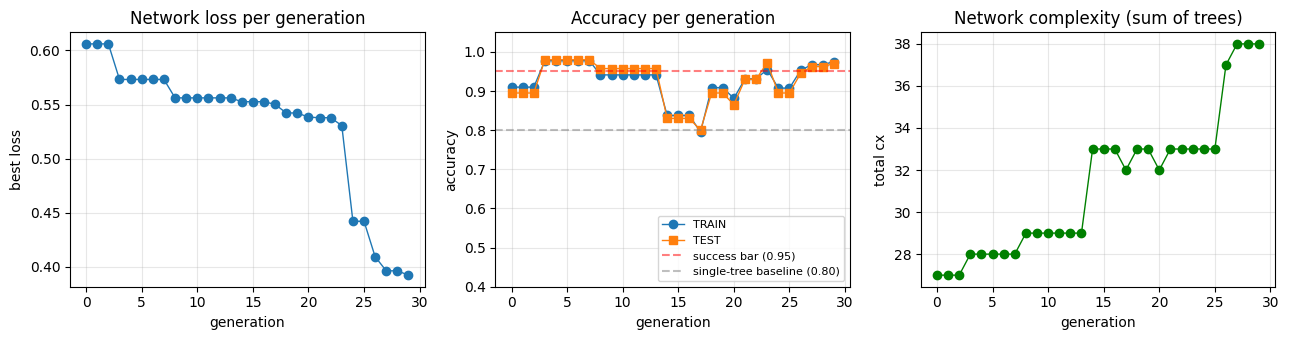

In [6]:
# Cell 4 — Training curves.
gens = [h['gen'] for h in history]
losses = [h['best_loss'] for h in history]
tr_accs = [h['best_train_acc'] for h in history]
te_accs = [h['best_test_acc'] for h in history]
cxs    = [h['best_cx'] for h in history]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
axes[0].plot(gens, losses, marker='o', lw=1)
axes[0].set_xlabel('generation'); axes[0].set_ylabel('best loss')
axes[0].set_title('Network loss per generation')
axes[0].grid(alpha=0.3)

axes[1].plot(gens, tr_accs, marker='o', lw=1, label='TRAIN')
axes[1].plot(gens, te_accs, marker='s', lw=1, label='TEST')
axes[1].axhline(0.95, color='red', ls='--', alpha=0.5, label='success bar (0.95)')
axes[1].axhline(0.80, color='gray', ls='--', alpha=0.5, label='single-tree baseline (0.80)')
axes[1].set_xlabel('generation'); axes[1].set_ylabel('accuracy')
axes[1].set_title('Accuracy per generation')
axes[1].set_ylim(0.4, 1.05)
axes[1].legend(loc='lower right', fontsize=8)
axes[1].grid(alpha=0.3)

axes[2].plot(gens, cxs, marker='o', lw=1, color='green')
axes[2].set_xlabel('generation'); axes[2].set_ylabel('total cx')
axes[2].set_title('Network complexity (sum of trees)')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. What did the network discover?

Print each tree slot's expression + visualize the layer-1 features applied to sample images. Interpretation question: do the discovered features map to human concepts (closed-loop vs vertical-stroke), or are they opaque pixel correlations?

In [7]:
# Cell 5.1 — Print the network.
print(best.network)

SymbolicNetwork(K=4, n_classes=2, cx=38):
  Layer 1:
    f0 = (max(image, step(image)) + (image + image))
    f1 = (sqrt(image) + sqrt(step(image)))
    f2 = (abs(image) - 1.10298)
    f3 = ((sqrt(image) > tanh(image)) + sign(image))
  Layer 2 (one tree per class):
    class_0 = (((f0 + f1) + f2) + f3)
    class_1 = (neg(f1) - log(f3))


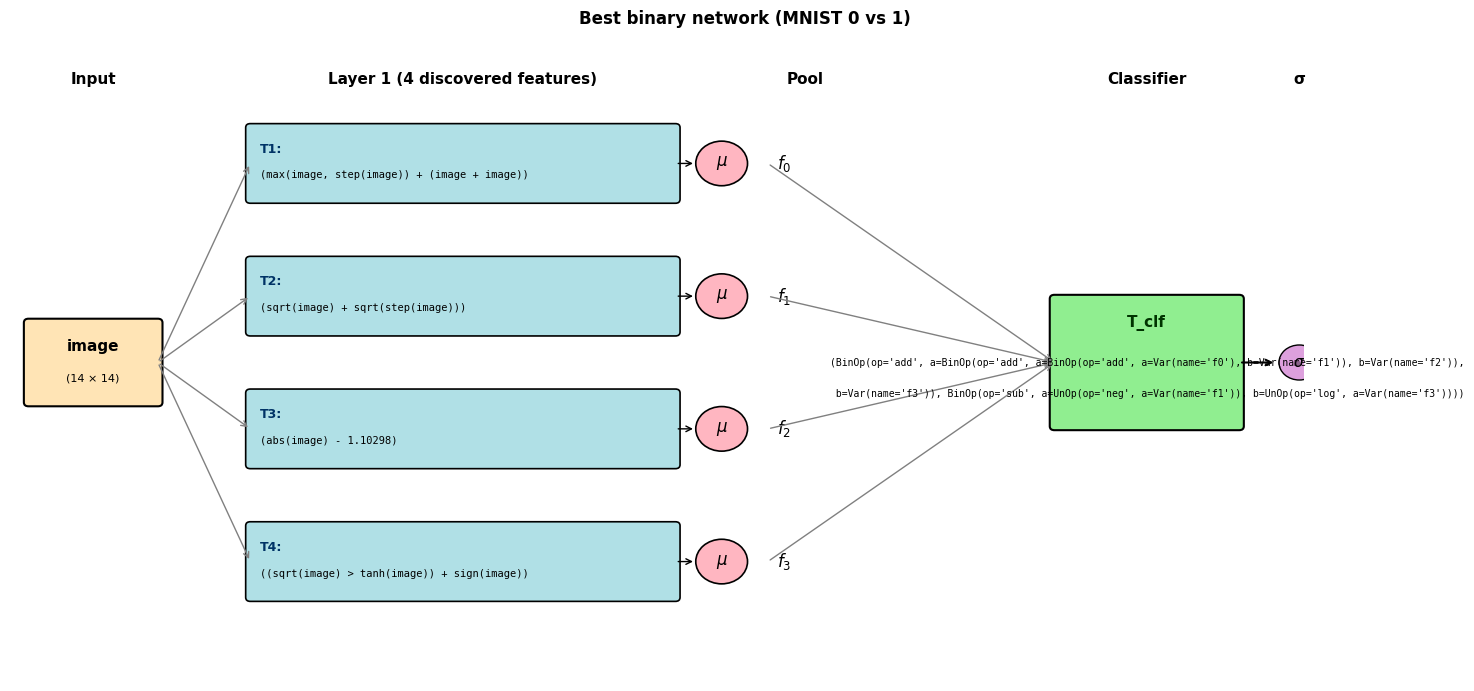

In [11]:
# Cell 5.1.5 — Architecture diagram (analog of keras plot_model / torchviz,
# but for a symbolic network where each "neuron" is a discovered expression).

def visualize_network_architecture(network, title=None, figsize=(15, 7),
                                    show_tree_graphs=True):
    """Render the network as a block diagram with each tree's expression
    inline. Layout:
        image → K layer-1 tree boxes → μ pool → f_k features → layer-2 box → σ → class
    """
    import matplotlib.patches as mpatches

    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(1, 1)
    ax = fig.add_subplot(gs[0])
    ax.set_xlim(0, 14); ax.set_ylim(0, 8); ax.axis('off')

    K = network.K
    # Vertical layout: K boxes evenly spaced from top to bottom
    y_positions = np.linspace(6.5, 1.5, K)

    # Input box
    ax.add_patch(mpatches.FancyBboxPatch(
        (0.2, 3.5), 1.4, 1.0, boxstyle='round,pad=0.05',
        facecolor='#FFE4B5', edgecolor='black', lw=1.5))
    ax.text(0.9, 4.2, 'image', ha='center', va='center', fontsize=11, weight='bold')
    ax.text(0.9, 3.8, '(14 × 14)', ha='center', va='center', fontsize=8)

    # Layer-1 tree boxes
    box_x, box_w = 2.6, 4.6
    for k, y in enumerate(y_positions):
        ax.add_patch(mpatches.FancyBboxPatch(
            (box_x, y - 0.45), box_w, 0.9,
            boxstyle='round,pad=0.05',
            facecolor='#B0E0E6', edgecolor='black', lw=1.2))
        tree_str = str(network.layer_1_trees[k])
        if len(tree_str) > 56:
            tree_str = tree_str[:53] + '...'
        ax.text(box_x + 0.1, y + 0.18,
                f'T{k+1}:',
                ha='left', va='center', fontsize=9, weight='bold', color='#003366')
        ax.text(box_x + 0.1, y - 0.15, tree_str,
                ha='left', va='center', fontsize=7.5, family='monospace')
        cx_k = tree_complexity(network.layer_1_trees[k]) \
            if 'tree_complexity' in dir() else None
        # arrow image -> tree
        ax.annotate('', xy=(box_x, y), xytext=(1.6, 4.0),
                    arrowprops=dict(arrowstyle='->', color='gray', lw=1))

        # μ pool circle
        cx = box_x + box_w + 0.5
        circle = mpatches.Circle((cx, y), 0.28,
                                 facecolor='#FFB6C1', edgecolor='black', lw=1.2)
        ax.add_patch(circle)
        ax.text(cx, y, r'$\mu$', ha='center', va='center', fontsize=12, weight='bold')
        ax.annotate('', xy=(cx - 0.28, y), xytext=(box_x + box_w, y),
                    arrowprops=dict(arrowstyle='->', color='black'))

        # feature label
        ax.text(cx + 0.6, y, f'$f_{k}$', ha='left', va='center', fontsize=12,
                family='serif', weight='bold')

        # arrow pool -> layer-2 box
        ax.annotate('', xy=(11.3, 4.0), xytext=(cx + 0.5, y),
                    arrowprops=dict(arrowstyle='->', color='gray', lw=1))

    # Layer-2 box
    ax.add_patch(mpatches.FancyBboxPatch(
        (11.3, 3.2), 2.0, 1.6, boxstyle='round,pad=0.05',
        facecolor='#90EE90', edgecolor='black', lw=1.5))
    ax.text(12.3, 4.5, 'T_clf', ha='center', va='center', fontsize=11, weight='bold',
            color='#003300')
    l2_str = str(network.layer_2_trees)
    # Wrap onto two lines if long
    if len(l2_str) > 22:
        # Split at a natural break if possible
        mid = len(l2_str) // 2
        # Find nearest space or operator within 5 chars of midpoint
        l2_a = l2_str[:mid]
        l2_b = l2_str[mid:]
        ax.text(12.3, 4.0, l2_a, ha='center', va='center', fontsize=7,
                family='monospace')
        ax.text(12.3, 3.6, l2_b, ha='center', va='center', fontsize=7,
                family='monospace')
    else:
        ax.text(12.3, 3.8, l2_str, ha='center', va='center', fontsize=8,
                family='monospace')

    # σ sigmoid + class
    ax.annotate('', xy=(13.7, 4.0), xytext=(13.3, 4.0),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
    sig = mpatches.Circle((13.95, 4.0), 0.22,
                          facecolor='#DDA0DD', edgecolor='black')
    ax.add_patch(sig)
    ax.text(13.95, 4.0, r'$\sigma$', ha='center', va='center', fontsize=11,
            weight='bold')

    # Column headers
    ax.text(0.9, 7.5, 'Input', ha='center', fontsize=11, weight='bold')
    ax.text(box_x + box_w / 2, 7.5, f'Layer 1 ({K} discovered features)',
            ha='center', fontsize=11, weight='bold')
    ax.text(8.6, 7.5, 'Pool', ha='center', fontsize=11, weight='bold')
    ax.text(12.3, 7.5, 'Classifier', ha='center', fontsize=11, weight='bold')
    ax.text(13.95, 7.5, 'σ', ha='center', fontsize=11, weight='bold')

    if title is None:
        title = (f'Symbolic network (K={K} features, total cx={network.complexity}) — '
                 f'each "neuron" is a discovered symbolic expression')
    fig.suptitle(title, fontsize=12, weight='bold', y=0.98)
    plt.tight_layout()
    return fig

# Draw the best network from the binary task
from tessera.expression.tree import complexity as tree_complexity
fig = visualize_network_architecture(best.network,
    title=f'Best binary network (MNIST {TARGET_A} vs {TARGET_B})')
plt.show()


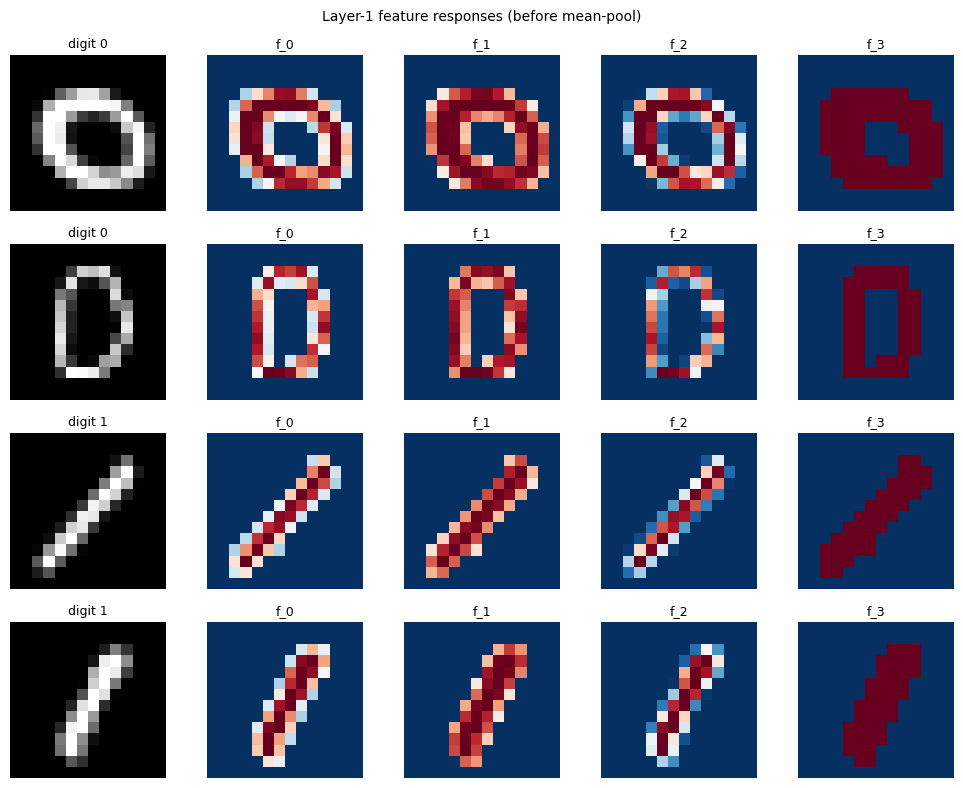

In [12]:
# Cell 5.2 — Visualize each layer-1 tree applied to a sample of each class.
def safe_eval_to_field(tree, image):
    """Evaluate tree on image; return 2D array (broadcast scalar if needed)."""
    try:
        out = eval_tree(tree, {'image': image}, fill_warmup=0.0)
        out = np.asarray(out, dtype=np.float64)
        if out.ndim == 0:
            out = np.full_like(image, float(out), dtype=np.float64)
        return out
    except Exception as e:
        return np.zeros_like(image)

samples_per_class = 2
K = best.network.K

j0_list = np.where(labels_test == 0)[0][:samples_per_class]
j1_list = np.where(labels_test == 1)[0][:samples_per_class]
sample_indices = list(j0_list) + list(j1_list)
sample_classes = [TARGET_A]*samples_per_class + [TARGET_B]*samples_per_class

fig, axes = plt.subplots(len(sample_indices), K+1, figsize=(2.0*(K+1), 2.0*len(sample_indices)))
if len(sample_indices) == 1:
    axes = axes[None, :]
for r, (idx, cls) in enumerate(zip(sample_indices, sample_classes)):
    img = imgs_test[idx]
    axes[r, 0].imshow(img, cmap='gray')
    axes[r, 0].set_title(f'digit {cls}', fontsize=9)
    axes[r, 0].axis('off')
    for k in range(K):
        field = safe_eval_to_field(best.network.layer_1_trees[k], img)
        axes[r, k+1].imshow(field, cmap='RdBu_r')
        axes[r, k+1].set_title(f'f_{k}', fontsize=9)
        axes[r, k+1].axis('off')
plt.suptitle('Layer-1 feature responses (before mean-pool)', fontsize=10)
plt.tight_layout()
plt.show()

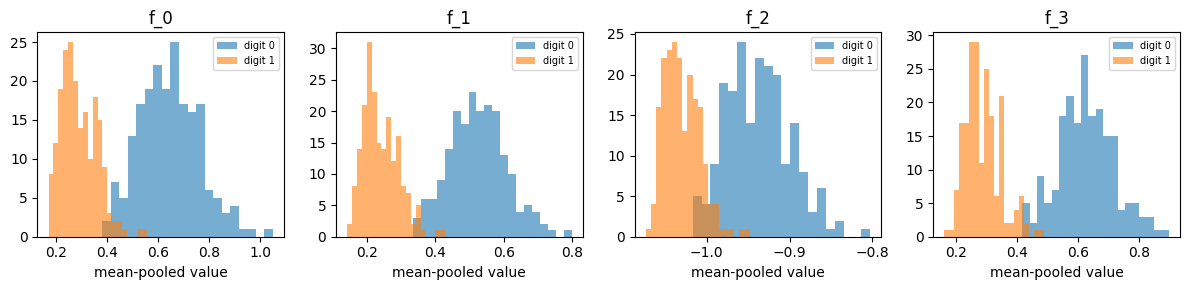

In [13]:
# Cell 5.3 — Feature distributions across TEST classes.
# For each f_k, plot the distribution of mean-pooled values across digit 0 vs digit 1.
# If a feature is informative, the two distributions should be visibly separated.

def feature_values(tree, images):
    vals = np.zeros(len(images), dtype=np.float64)
    for i, img in enumerate(images):
        out = safe_eval_to_field(tree, img)
        vals[i] = np.nanmean(out)
    return vals

fig, axes = plt.subplots(1, K, figsize=(3*K, 3))
if K == 1:
    axes = [axes]
for k in range(K):
    vals = feature_values(best.network.layer_1_trees[k], imgs_test)
    axes[k].hist(vals[labels_test==0], bins=20, alpha=0.6, label=f'digit {TARGET_A}', color='C0')
    axes[k].hist(vals[labels_test==1], bins=20, alpha=0.6, label=f'digit {TARGET_B}', color='C1')
    axes[k].set_title(f'f_{k}')
    axes[k].set_xlabel('mean-pooled value')
    axes[k].legend(fontsize=7)
plt.tight_layout()
plt.show()

## 6. Final scoreboard

Compare to the Milestone A success criterion and the existing single-tree baseline.

In [14]:
# Cell 6 — Scoreboard.
tr_acc = best.accuracy
te_acc = network_accuracy(best.network, imgs_test, labels_test)

print('=' * 55)
print(f'Milestone A — MNIST {TARGET_A} vs {TARGET_B}, K={best.network.K}, pop={cfg.pop_size}, gens={cfg.n_gens}')
print('=' * 55)
print(f'  TRAIN accuracy:   {tr_acc:.3f}  ({int(tr_acc * len(labels_train))} / {len(labels_train)})')
print(f'  TEST accuracy:    {te_acc:.3f}  ({int(te_acc * len(labels_test))} / {len(labels_test)})')
print(f'  Network cx:       {best.network.complexity}')
print()
print(f'  Single-tree baseline (existing benchmark, 0-vs-rest): TEST 0.80')
print(f'  Milestone A success bar:                              TEST > 0.95')
print()
if te_acc > 0.95:
    print('  >>> SUCCESS: TEST accuracy exceeds Milestone A target.')
elif te_acc > 0.80:
    print('  >>> PROGRESS: TEST accuracy beats single-tree baseline but below 0.95 target.')
    print('      Try larger pop_size / n_gens, or K, or fewer training samples.')
else:
    print('  >>> NOT YET: TEST accuracy ≤ single-tree baseline.')
    print('      Architecture may need infrastructure refinement (see hybrid_symbolic_networks.md §5).')

Milestone A — MNIST 0 vs 1, K=4, pop=30, gens=30
  TRAIN accuracy:   0.975  (780 / 800)
  TEST accuracy:    0.970  (388 / 400)
  Network cx:       38

  Single-tree baseline (existing benchmark, 0-vs-rest): TEST 0.80
  Milestone A success bar:                              TEST > 0.95

  >>> SUCCESS: TEST accuracy exceeds Milestone A target.


## 7. Full 10-digit MNIST (one-vs-rest)

The 2-class case validated the architecture. Now scale to all 10 digits via **one-vs-rest**: train 10 separate binary networks (each `digit d vs everything else`), then argmax their scores to predict the digit.

This is the simplest 10-class extension that reuses the binary architecture; a "proper" multi-class would use a single network with 10 layer-2 trees (Milestone C from the research note).

Setup:
- 200 train + 100 test images per class → 2000 train / 1000 test total
- 10 networks, each K=4, pop=30, gens=15 — with JAX
- Combined prediction: `argmax(scores_per_digit)`

Result includes a **confusion matrix** showing which digits get confused with which, and a **per-digit accuracy bar chart**.


In [ ]:
# Cell 7.2 — Two approaches to 10-class, now WITH the spatial channel bank.
#  (A) Direct multi-class (n_classes=10, single network)
#  (B) One-vs-rest (10 balanced binary networks, argmax)
# Both use input_channels=(image,gx,gy,lap) + quadrant pooling + JAX.

N_PER_TRAIN_OVR = 200
N_PER_TEST_OVR  = 100
CHANNELS = ("image", "gx", "gy", "lap")

print('Loading full MNIST 0-9...')
imgs_full_train_list, labels_full_train_list = [], []
imgs_full_test_list,  labels_full_test_list  = [], []
for d in range(10):
    idx = rng_data.permutation(np.where(y == d)[0])
    tr = idx[:N_PER_TRAIN_OVR]
    te = idx[N_PER_TRAIN_OVR:N_PER_TRAIN_OVR + N_PER_TEST_OVR]
    imgs_full_train_list.extend(X[tr]);  labels_full_train_list.extend([d]*N_PER_TRAIN_OVR)
    imgs_full_test_list.extend(X[te]);   labels_full_test_list.extend([d]*N_PER_TEST_OVR)

imgs_full_train = np.stack([downsample_2x(im) for im in imgs_full_train_list], axis=0)
imgs_full_test  = np.stack([downsample_2x(im) for im in imgs_full_test_list],  axis=0)
labels_full_train = np.array(labels_full_train_list)
labels_full_test  = np.array(labels_full_test_list)
print(f'  TRAIN {imgs_full_train.shape}, TEST {imgs_full_test.shape}, channels={CHANNELS}')

from tessera.experimental.symbolic_network import (
    evaluate_network_jax_batch, evaluate_network_batch,
)

# --------- Approach A: Direct multi-class single network ---------
print('\n=== Approach A: Direct 10-class network + channel bank ===')
cfg_mc = NetworkGPConfig(
    pop_size=80, n_gens=40, K=8, n_classes=10, n_regions=4,
    input_channels=CHANNELS,
    layer_1_max_depth=3, layer_2_max_depth=3,
    enable_2d=False, parsimony=0.001,
    normalize_parsimony_by_classes=True,   # don't over-penalize 10 trees
    seed=SEED, early_stop_patience=12,
    verbose=False, use_jax_eval=True,
)
t0 = time.time()
best_mc, _ = run_network_gp(imgs_full_train, labels_full_train, cfg_mc,
                            imgs_full_test, labels_full_test)
mc_test_acc = network_accuracy(best_mc.network, imgs_full_test, labels_full_test, use_jax=True)
print(f'  Direct 10-class: TRAIN={best_mc.accuracy:.3f}, TEST={mc_test_acc:.3f}, '
      f'cx={best_mc.network.complexity}, nfeat={best_mc.network.n_features}, '
      f'runtime={time.time()-t0:.1f}s')

# --------- Approach B: One-vs-rest (10 balanced binary networks) ---------
print('\n=== Approach B: One-vs-rest (10 balanced binary nets) + channel bank ===')

def make_balanced_binary(imgs, labels, target_digit, rng_balance):
    pos_idx = np.where(labels == target_digit)[0]
    neg_idx = np.where(labels != target_digit)[0]
    n = len(pos_idx)
    neg_sample = rng_balance.choice(neg_idx, size=n, replace=False)
    idx = np.concatenate([pos_idx, neg_sample]); rng_balance.shuffle(idx)
    return imgs[idx], (labels[idx] == target_digit).astype(int)

networks_10 = {}
t_total = time.time()
for d in range(10):
    rng_balance = np.random.default_rng(SEED + d)
    imgs_bal, labels_bal = make_balanced_binary(imgs_full_train, labels_full_train, d, rng_balance)
    imgs_bal_te, labels_bal_te = make_balanced_binary(imgs_full_test, labels_full_test, d, rng_balance)
    cfg_d = NetworkGPConfig(
        pop_size=30, n_gens=15, K=4, n_classes=2, n_regions=4,
        input_channels=CHANNELS,
        enable_2d=False, parsimony=0.002,
        seed=SEED + d, early_stop_patience=8,
        verbose=False, use_jax_eval=True,
    )
    t0 = time.time()
    best_d, _ = run_network_gp(imgs_bal, labels_bal, cfg_d, imgs_bal_te, labels_bal_te)
    networks_10[d] = best_d.network
    bin_te_acc = network_accuracy(best_d.network, imgs_bal_te, labels_bal_te, use_jax=True)
    print(f'  digit {d}: balanced TEST={bin_te_acc:.3f}  cx={best_d.network.complexity}  ({time.time()-t0:.1f}s)')
print(f'Total one-vs-rest time: {time.time()-t_total:.1f}s')

print('\nCombining via argmax(p1 - p0) across 10 nets...')
test_scores_10 = np.zeros((len(imgs_full_test), 10), dtype=np.float64)
for d in range(10):
    sc_2 = evaluate_network_jax_batch(networks_10[d], imgs_full_test)
    if sc_2 is None:
        sc_2 = evaluate_network_batch(networks_10[d], imgs_full_test)
    test_scores_10[:, d] = sc_2[:, 1] - sc_2[:, 0]
preds_10 = test_scores_10.argmax(axis=1)
overall_acc = float(np.mean(preds_10 == labels_full_test))

print()
print('=' * 60)
print(f'Approach A (direct n_classes=10 + channels) TEST: {mc_test_acc:.3f}')
print(f'Approach B (one-vs-rest + channels)         TEST: {overall_acc:.3f}')
print(f'Chance (10-class): 0.10')
print('=' * 60)


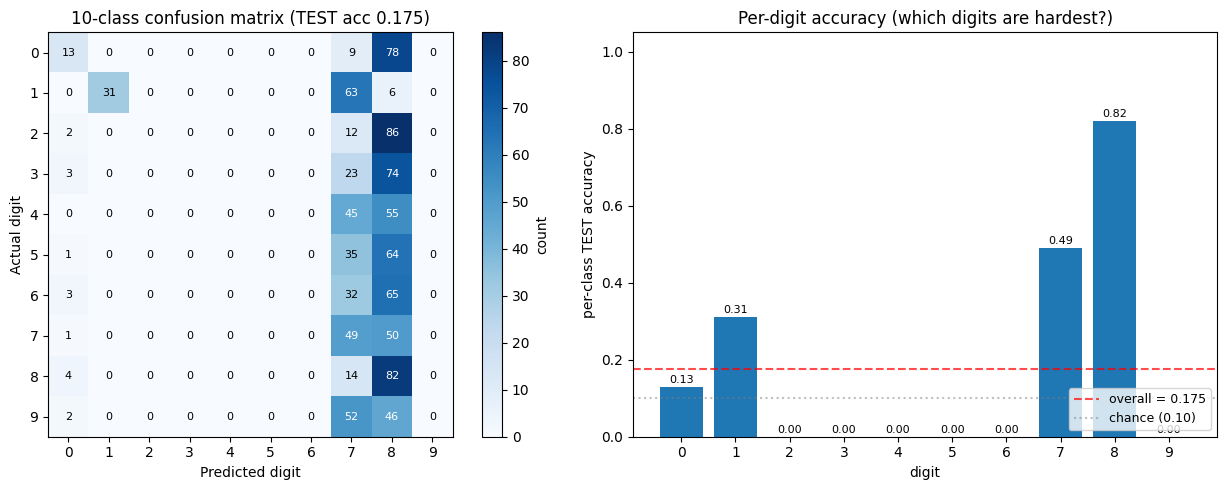


Best-recognized digit:  8 (0.820 accuracy)
Worst-recognized digit: 2 (0.000 accuracy)
Top confusion: digit 2 most often confused with digit 7 (12 times)


In [16]:
# Cell 7.3 — Confusion matrix + per-digit accuracy.

# Confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(labels_full_test, preds_10)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: confusion matrix heatmap
ax = axes[0]
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xlabel('Predicted digit'); ax.set_ylabel('Actual digit')
ax.set_title(f'10-class confusion matrix (TEST acc {overall_acc:.3f})')
threshold = cm.max() / 2
for i in range(10):
    for j in range(10):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > threshold else 'black', fontsize=8)
plt.colorbar(im, ax=ax, label='count')

# Right: per-digit accuracy bar chart
ax = axes[1]
per_digit_acc = cm.diagonal() / cm.sum(axis=1)
bars = ax.bar(range(10), per_digit_acc, color='C0')
for bar, acc in zip(bars, per_digit_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{acc:.2f}', ha='center', fontsize=8)
ax.axhline(overall_acc, color='red', ls='--', alpha=0.7,
            label=f'overall = {overall_acc:.3f}')
ax.axhline(0.10, color='gray', ls=':', alpha=0.5, label='chance (0.10)')
ax.set_xlabel('digit'); ax.set_ylabel('per-class TEST accuracy')
ax.set_title('Per-digit accuracy (which digits are hardest?)')
ax.set_xticks(range(10))
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

# Print misclassification summary
worst_digit = int(np.argmin(per_digit_acc))
best_digit = int(np.argmax(per_digit_acc))
print(f'\nBest-recognized digit:  {best_digit} ({per_digit_acc[best_digit]:.3f} accuracy)')
print(f'Worst-recognized digit: {worst_digit} ({per_digit_acc[worst_digit]:.3f} accuracy)')
print(f'Top confusion: digit {worst_digit} most often confused with '
      f'digit {int(np.argsort(cm[worst_digit])[-2])} '
      f'({cm[worst_digit, int(np.argsort(cm[worst_digit])[-2])]} times)')


## What's next

Per `docs/research/hybrid_symbolic_networks.md`:

- **Milestone B**: Add neural prepass (small CNN teacher → extract filters → convert to symbolic seed trees → inject into network initial population). This is Hybrid #2 — detect-then-seed at the network composition layer.
- **Milestone C**: Scale up to full 10-class MNIST with K=16, cross-entropy loss.
- **Milestone D**: Cross-domain validation (Fashion-MNIST, CIFAR-10 if scope allows).

If Milestone A's TEST accuracy is below 0.95 but above 0.80, the architecture is working but the search budget or K is too small. If it's at or below 0.80, refer to §5 of the research note for which infrastructure piece likely needs work.